# 📚 Academic Research Summarizer
## Multi-Agent System using LangGraph + Groq + Tavily

---

### 🏗️ Architecture: Supervisor Pattern (Manager → Workers)

```
              Supervisor
             /     |     \
     Search Agent  Extraction Agent  Synthesis Agent
```

**Flow:**
```
User Topic → Supervisor → Search Agent → Supervisor → Extraction Agent → Supervisor → Synthesis Agent → END
```

**What each agent does:**
| Agent | Role | Tools Used |
|-------|------|------------|
| Search Agent | Find 10 relevant academic papers on the topic | `Tavily Search` |
| Extraction Agent | Extract key findings from each paper | `Groq LLM` |
| Synthesis Agent | Identify contradictions, write literature review | `Groq LLM` |
| Supervisor | Decides who runs next | Rule-based logic |

---

### 🔄 How this differs from Project 1 (Financial Due Diligence)

| Aspect | Project 1 (Finance) | Project 2 (Research) |
|--------|--------------------|-----------------------|
| Data source | Yahoo Finance + Tavily | Tavily (academic focused) |
| Agent count | 3 workers | 3 workers (same pattern!) |
| LLM task | Analyze numbers | Synthesize ideas |
| Output | Investment memo | Literature review |
| Key challenge | Financial metrics | Finding contradictions |

**Same architecture, completely different domain.** That's the power of Supervisor Pattern.

### Step 0: Loading Environment & Liabraries

In [1]:
from dotenv import load_dotenv
load_dotenv()
import os

In [2]:
# pydantic: For structured data validation
from pydantic import BaseModel, Field

# LangChain components for prompts and parsing
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.output_parsers import PydanticOutputParser

# LangChain message types
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# LangChain runnable
from langchain_core.runnables import RunnablePassthrough

# LangGraph
from langgraph.graph import StateGraph, END

c:\Users\HP\anaconda3\envs\fresh_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 1: Loading/Initializing LLM

In [3]:
from langchain_groq import ChatGroq

# Groq automatically reads GROQ_API_KEY from environment variables

model = ChatGroq(
    model="openai/gpt-oss-120b",   # or llama-3.3-70b-versatile
    temperature=0.7
)

llm = model

In [4]:
# ---- TEST ----
try:
    response = llm.invoke("Say hello in one sentence.")
    print("✅ Groq LLM initialized successfully")
    print("Response:", response.content)

except Exception as e:
    print("❌ Groq LLM initialization failed")
    print(e)

✅ Groq LLM initialized successfully
Response: Hello! I hope you're having a wonderful day.


## 📋 Step 2 — Shared State Definition

**Concept:** All agents share one `State` object — the "whiteboard" everyone reads from and writes to.

Compare with Project 1:
```
Project 1 State:          Project 2 State:
┌──────────────────┐      ┌──────────────────────┐
│ company_name     │      │ research_topic        │  ← input
│ financial_data   │      │ raw_papers            │  ← Search Agent writes
│ news_data        │      │ extracted_findings    │  ← Extraction Agent writes
│ investment_memo  │      │ literature_review     │  ← Synthesis Agent writes
│ next_agent       │      │ next_agent            │  ← Supervisor writes
│ messages         │      │ messages              │  ← running log
└──────────────────┘      └──────────────────────┘
```
Same structure, different field names. Same pattern!

In [7]:
from typing import TypedDict, Optional


class AgentState(TypedDict):
    """
    Shared whiteboard for all agents in the research pipeline.

    Fields are filled in progressively as agents run:
      START: only research_topic is set
      After Search Agent:     raw_papers filled
      After Extraction Agent: extracted_findings filled
      After Synthesis Agent:  literature_review filled → DONE
    """

    # --- Input ---
    # The research topic entered by the user
    # e.g., "transformer attention mechanisms", "climate change and mental health"
    research_topic: str

    # --- Supervisor control ---
    # The supervisor writes here to tell LangGraph which node runs next
    next_agent: str    # "search_agent" | "extraction_agent" | "synthesis_agent" | "END"

    # --- Agent outputs (filled progressively) ---

    # Search Agent: list of papers found (stored as formatted string for LLM readability)
    # Contains: titles, abstracts, URLs, authors from Tavily search results
    raw_papers: Optional[str]

    # Extraction Agent: structured findings from each paper
    # Contains: main claim, methodology, key results, limitations per paper
    extracted_findings: Optional[str]

    # Synthesis Agent: the final literature review
    # Contains: themes, contradictions, gaps, and a cohesive narrative
    literature_review: Optional[str]

    # --- Conversation log ---
    messages: list


print("✅ AgentState defined!")
print("   Fields:", list(AgentState.__annotations__.keys()))

✅ AgentState defined!
   Fields: ['research_topic', 'next_agent', 'raw_papers', 'extracted_findings', 'literature_review', 'messages']


## 🔍 Step 3 — Search Tool (Tavily Academic Search)

**Concept:** Tools are **plain Python functions** — no LLM. They fetch raw data.

For academic research we run **3 targeted Tavily searches** to maximize paper diversity:
1. Core topic papers (recent, peer-reviewed)
2. Survey/review papers (give broad overview)
3. Contrasting/critical perspectives (surfaces contradictions)

This 3-query strategy is much more effective than one broad search.

In [8]:
from tavily import TavilyClient


def search_academic_papers(topic: str, max_results: int = 4) -> str:
    """
    Search for academic papers on a given research topic.

    Strategy: Run 3 targeted searches to get diverse paper perspectives.
    - Search 1: Recent peer-reviewed papers on the core topic
    - Search 2: Survey and review papers (broad overviews)
    - Search 3: Critical/contrasting perspectives (find contradictions)

    Args:
        topic: The research topic to search for
        max_results: Papers per search (3 searches × max_results = total papers)

    Returns:
        Formatted string of all papers found across all searches
    """
    client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
    all_papers = []
    paper_count = 0

    # --- Search 1: Core recent papers ---
    # Target academic sources: arxiv, pubmed, scholar, semantic scholar
    print("      → Search 1: Recent papers on core topic...")
    core_results = client.search(
        query=f"{topic} research paper academic study 2022 2023 2024",
        search_depth="advanced",
        max_results=max_results,
        include_answer=True,
        # Bias toward academic domains
        include_domains=["arxiv.org", "pubmed.ncbi.nlm.nih.gov",
                         "scholar.google.com", "semanticscholar.org",
                         "researchgate.net", "nature.com",
                         "science.org", "springer.com"]
    )

    all_papers.append("=" * 60)
    all_papers.append("SECTION 1: CORE RECENT PAPERS")
    all_papers.append("=" * 60)

    # Tavily's AI-generated summary of all search results
    if core_results.get("answer"):
        all_papers.append(f"Tavily Summary: {core_results['answer']}\n")

    for result in core_results.get("results", []):
        paper_count += 1
        all_papers.append(
            f"[Paper {paper_count}]\n"
            f"  Title  : {result.get('title', 'No title')}\n"
            f"  URL    : {result.get('url', 'N/A')}\n"
            # content contains the paper abstract/introduction snippet
            f"  Content: {result.get('content', '')[:600]}\n"
        )

    # --- Search 2: Survey & Review papers ---
    # Survey papers synthesize many studies — great for understanding the field broadly
    print("      → Search 2: Survey and review papers...")
    survey_results = client.search(
        query=f"{topic} systematic review survey literature overview",
        search_depth="advanced",
        max_results=max_results,
        include_answer=True,
        include_domains=["arxiv.org", "pubmed.ncbi.nlm.nih.gov",
                         "scholar.google.com", "semanticscholar.org",
                         "researchgate.net", "nature.com"]
    )

    all_papers.append("\n" + "=" * 60)
    all_papers.append("SECTION 2: SURVEY & REVIEW PAPERS")
    all_papers.append("=" * 60)

    if survey_results.get("answer"):
        all_papers.append(f"Tavily Summary: {survey_results['answer']}\n")

    for result in survey_results.get("results", []):
        paper_count += 1
        all_papers.append(
            f"[Paper {paper_count}]\n"
            f"  Title  : {result.get('title', 'No title')}\n"
            f"  URL    : {result.get('url', 'N/A')}\n"
            f"  Content: {result.get('content', '')[:600]}\n"
        )

    # --- Search 3: Contrasting / Critical Perspectives ---
    # Critical papers challenge prevailing views — key for finding contradictions
    # The Extraction Agent will use these to surface disagreements in the field
    print("      → Search 3: Critical and contrasting perspectives...")
    critical_results = client.search(
        query=f"{topic} limitations challenges criticism debate controversy",
        search_depth="advanced",
        max_results=max_results,
        include_answer=True
    )

    all_papers.append("\n" + "=" * 60)
    all_papers.append("SECTION 3: CRITICAL & CONTRASTING VIEWS")
    all_papers.append("=" * 60)

    if critical_results.get("answer"):
        all_papers.append(f"Tavily Summary: {critical_results['answer']}\n")

    for result in critical_results.get("results", []):
        paper_count += 1
        all_papers.append(
            f"[Paper {paper_count}]\n"
            f"  Title  : {result.get('title', 'No title')}\n"
            f"  URL    : {result.get('url', 'N/A')}\n"
            f"  Content: {result.get('content', '')[:600]}\n"
        )

    print(f"      → Total papers collected: {paper_count}")
    return "\n".join(all_papers)


print("✅ Academic search tool defined!")
print("   Strategy: 3 searches × 4 papers = ~12 papers per topic")

✅ Academic search tool defined!
   Strategy: 3 searches × 4 papers = ~12 papers per topic


## 🤖 Step 4 — Worker Agent #1: Search Agent

**Role:** Call the search tool → ask LLM to organize papers into a clean structured list

**Key learning:** The LLM's job here is NOT analysis — it's **organization and deduplication**.
Raw Tavily results can have duplicates and noise. The LLM cleans this up.

In [15]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage


def search_agent(state: dict) -> dict:
    """
    Worker Agent #1: Find relevant academic papers on the research topic.

    Two steps:
    1. Use Tavily tool to fetch raw search results (3 targeted queries)
    2. Use LLM to clean, deduplicate, and organize into a structured paper list

    Args:
        state: Shared AgentState — reads 'research_topic'

    Returns:
        Dict with 'raw_papers' filled in
    """
    print("\n" + "="*55)
    print("🔍 SEARCH AGENT: Finding academic papers...")
    print("="*55)

    topic = state["research_topic"]
    print(f"   Topic: {topic}")

    # Step 1: Run 3 targeted Tavily searches (no LLM — pure data fetching)
    print("   Running academic searches via Tavily...")
    raw_search_results = search_academic_papers(topic, max_results=4)
    print(f"   Fetched {len(raw_search_results)} chars of raw search data")

    # Step 2: LLM organizes and cleans the raw results
    # Why: Tavily can return duplicates, paywalled pages, or irrelevant results
    # The LLM filters and standardizes the paper list
    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0,      # 0 = deterministic; we want consistent organization
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a research librarian specializing in
        academic literature. Your job is to organize search results into a
        clean, structured list of papers — removing duplicates and
        irrelevant results."""),

        HumanMessage(content=f"""
        The researcher is studying: "{topic}"

        Below are raw search results from 3 academic queries.
        Please organize them into a clean numbered list of papers.

        For each paper, output EXACTLY this format:
        ---
        PAPER [N]
        Title     : [paper title]
        Source    : [URL or journal name]
        Relevance : [1 sentence — why this paper matters for the topic]
        Abstract  : [2-4 sentence summary of what the paper is about]
        ---

        Rules:
        - Remove obvious duplicates (keep the one with more info)
        - Skip clearly irrelevant results
        - Aim for 8-12 high-quality, diverse papers
        - Prioritize peer-reviewed academic sources

        RAW SEARCH RESULTS:
        {raw_search_results}
        """)
    ]

    print("   Asking LLM to organize and clean paper list...")
    response = llm.invoke(messages)
    organized_papers = response.content

    print(f"   ✅ Search Agent complete! Organized paper list ready.")

    # Return only the fields we updated
    return {
        "raw_papers": organized_papers,
        "messages": state["messages"] + [
            {"role": "assistant",
             "content": f"[Search Agent] Found and organized papers on: {topic}"}
        ]
    }


print("✅ Search Agent defined!")

✅ Search Agent defined!


## 🔬 Step 5 — Worker Agent #2: Extraction Agent

**Role:** Go paper-by-paper and extract structured findings from each one

**Why this agent exists separately:**
- Extraction is a **different cognitive task** from finding or writing
- We need a consistent schema per paper (claim, method, result, limitation)
- Isolated extraction makes the Synthesis Agent's job much easier

**Key learning:** This agent produces **structured data** (not prose), which the next agent consumes.

In [16]:
def extraction_agent(state: dict) -> dict:
    """
    Worker Agent #2: Extract structured key findings from each paper.

    For every paper the Search Agent found, this agent extracts:
    - Main claim/thesis
    - Methodology used
    - Key results/findings
    - Limitations acknowledged
    - Research gap identified

    This structured output is what the Synthesis Agent needs to:
    (a) find contradictions between papers
    (b) identify research gaps across the field

    Args:
        state: Shared AgentState — reads 'research_topic' and 'raw_papers'

    Returns:
        Dict with 'extracted_findings' filled in
    """
    print("\n" + "="*55)
    print("🔬 EXTRACTION AGENT: Extracting findings from papers...")
    print("="*55)

    topic       = state["research_topic"]
    raw_papers  = state.get("raw_papers", "No papers available.")

    print(f"   Topic       : {topic}")
    print(f"   Papers input: ✅ ({len(raw_papers)} chars from Search Agent)")

    # This agent does PURE LLM work — no external tools needed
    # The LLM reads the organized paper list and extracts structured data
    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0,      # Must be 0 — extraction should be factual, not creative
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a meticulous academic researcher.
        Your task is to carefully read paper summaries and extract structured
        findings using a consistent schema. Be precise and factual.
        Do not add information not present in the source material."""),

        HumanMessage(content=f"""
        Research Topic: "{topic}"

        For each paper below, extract its key information using EXACTLY this schema:

        ════════════════════════════════════
        PAPER [N]: [Title]
        ════════════════════════════════════
        Main Claim      : [The central argument or hypothesis of this paper]
        Methodology     : [How the research was conducted — experiment, survey, meta-analysis, etc.]
        Key Findings    : [The most important results or conclusions — be specific]
        Evidence Level  : [Strong / Moderate / Weak — based on methodology rigor]
        Limitations     : [What the paper itself admits it cannot fully address]
        Research Gap    : [What future work this paper suggests is needed]
        Agrees With     : [List any other papers in this set it corroborates — or "None identified"]
        Contradicts     : [List any other papers in this set it contradicts — or "None identified"]
        ════════════════════════════════════

        IMPORTANT: Fill "Agrees With" and "Contradicts" by comparing across papers.
        This is critical for the next agent to write about contradictions in the field.

        PAPERS TO ANALYZE:
        {raw_papers}
        """)
    ]

    print("   Asking LLM to extract structured findings from each paper...")
    response = llm.invoke(messages)
    extracted = response.content

    print(f"   ✅ Extraction Agent complete! ({len(extracted)} chars of structured findings)")

    return {
        "extracted_findings": extracted,
        "messages": state["messages"] + [
            {"role": "assistant",
             "content": f"[Extraction Agent] Key findings extracted from all papers on: {topic}"}
        ]
    }


print("✅ Extraction Agent defined!")

✅ Extraction Agent defined!


## 📝 Step 6 — Worker Agent #3: Synthesis Agent

**Role:** Read all extracted findings → write a full academic literature review

**What makes this hard (and interesting):**
- Must identify **themes** across papers (grouping, not just listing)
- Must surface **contradictions** where papers disagree
- Must identify **research gaps** (what the field hasn't solved yet)
- Must write in **academic prose** (cohesive, cited, structured)

**Temperature 0.4** — slightly higher than extraction agents because we want flowing prose.

In [17]:
def synthesis_agent(state: dict) -> dict:
    """
    Worker Agent #3: Synthesize all findings into a literature review.

    This is the most intellectually demanding agent:
    - Groups papers by theme (not just lists them)
    - Identifies where papers agree vs. contradict each other
    - Spots gaps in the current body of research
    - Writes a cohesive academic narrative

    This agent is DOWNSTREAM of both Search and Extraction agents.
    The Supervisor ensures it only runs after both have completed.

    Args:
        state: Shared AgentState — reads 'research_topic',
               'raw_papers', and 'extracted_findings'

    Returns:
        Dict with 'literature_review' filled in
    """
    print("\n" + "="*55)
    print("📝 SYNTHESIS AGENT: Writing literature review...")
    print("="*55)

    topic              = state["research_topic"]
    extracted_findings = state.get("extracted_findings", "No findings available.")
    raw_papers         = state.get("raw_papers", "")

    print(f"   Topic             : {topic}")
    print(f"   Extracted findings: ✅ ({len(extracted_findings)} chars)")
    print(f"   Paper list        : ✅ ({len(raw_papers)} chars)")

    # # temperature=0.4: We need coherent academic writing, not just facts
    # # Higher than extraction (0.0) but lower than creative writing (0.7+)
    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.4,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a senior academic researcher with expertise
        in writing comprehensive literature reviews. Your reviews are known for:
        - Identifying meaningful themes across disparate papers
        - Fairly representing contradictions and debates in the field
        - Pinpointing genuine research gaps (not just restatements)
        - Clear, precise academic prose that is also accessible"""),

        HumanMessage(content=f"""
        Write a comprehensive literature review on: "{topic}"

        Use the extracted findings below as your source material.

        Structure your review EXACTLY as follows:

        ════════════════════════════════════════════════════
        LITERATURE REVIEW: {topic.upper()}
        ════════════════════════════════════════════════════

        1. INTRODUCTION
        [Why is this topic important? What is the scope of this review?
         How many papers were reviewed? — 2-3 paragraphs]

        2. THEMATIC OVERVIEW
        [Group papers into 3-4 major themes. For each theme:
         - Theme name and brief description
         - Which papers belong to it and what they collectively show
         - How this theme advances understanding of the topic]

        3. KEY FINDINGS ACROSS THE LITERATURE
        [What do most papers agree on? What are the strongest, most
         replicated findings in the field? Cite papers by title.]

        4. CONTRADICTIONS AND DEBATES
        [Where do papers DISAGREE? Be specific:
         - State the contradiction clearly (Paper A claims X, Paper B claims Y)
         - Explain WHY they might differ (methodology, context, sample size)
         - What does this disagreement mean for the field?
         If there are no clear contradictions, identify tensions or nuances.]

        5. RESEARCH GAPS AND FUTURE DIRECTIONS
        [What questions remain unanswered? What methodologies are underused?
         What populations or contexts are understudied?
         Suggest 3-5 specific, actionable future research directions.]

        6. CONCLUSION
        [Summarize the state of the field in 1 paragraph.
         What is the most important takeaway for a researcher entering this area?]

        ════════════════════════════════════════════════════
        Note: This review was generated by an AI research assistant.
        Always verify citations and claims against original sources.
        ════════════════════════════════════════════════════

        EXTRACTED PAPER FINDINGS:
        {extracted_findings}
        """)
    ]

    print("   Asking LLM to synthesize findings into literature review...")
    response = llm.invoke(messages)
    review = response.content

    print(f"   ✅ Synthesis Agent complete! ({len(review)} chars)")

    return {
        "literature_review": review,
        "messages": state["messages"] + [
            {"role": "assistant",
             "content": f"[Synthesis Agent] Literature review written for: {topic}"}
        ]
    }


print("✅ Synthesis Agent defined!")

✅ Synthesis Agent defined!


## 🎯 Step 7 — Supervisor Agent

**Concept:** The Supervisor does NO research or writing. It only decides who runs next.

Notice how similar this is to Project 1's supervisor — **same logic, different field names**:
```python
# Project 1 checks:        # Project 2 checks:
has_financial_data?    →   has_raw_papers?
has_news_data?         →   has_extracted_findings?
has_memo?              →   has_literature_review?
```
This shows the **true power of Supervisor Architecture** — the pattern is reusable.

In [18]:
def supervisor(state: dict) -> dict:
    """
    The Supervisor: decides which agent runs next.

    Called by LangGraph between every agent execution.
    Uses rule-based routing — checks what's missing in state.

    Compare with Project 1:
      P1: financial_data → news_data → investment_memo
      P2: raw_papers → extracted_findings → literature_review
    Same logic, different field names!
    """
    print("\n" + "-"*55)
    print("🎯 SUPERVISOR: Deciding next step...")

    # Check pipeline progress by inspecting what's been filled in
    has_papers   = bool(state.get("raw_papers"))
    has_findings = bool(state.get("extracted_findings"))
    has_review   = bool(state.get("literature_review"))

    # Print the current pipeline status for visibility
    print(f"   raw_papers          : {'✅' if has_papers   else '❌ (needed)'}")
    print(f"   extracted_findings  : {'✅' if has_findings else '❌ (needed)'}")
    print(f"   literature_review   : {'✅' if has_review   else '❌ (needed)'}")

    # Rule-based routing — first matching rule wins
    if not has_papers:
        # Nothing collected yet → search for papers first
        next_step = "search_agent"
        reason    = "No papers collected yet — starting search"

    elif not has_findings:
        # Papers found but not analyzed → extract findings
        next_step = "extraction_agent"
        reason    = "Papers ready — extracting structured findings"

    elif not has_review:
        # Findings extracted but review not written → synthesize
        next_step = "synthesis_agent"
        reason    = "Findings ready — writing literature review"

    else:
        # All done!
        next_step = "END"
        reason    = "Literature review complete — pipeline finished"

    print(f"   Decision : → {next_step}")
    print(f"   Reason   : {reason}")

    # Write decision to state — LangGraph's router will read 'next_agent'
    return {"next_agent": next_step}


print("✅ Supervisor defined!")

✅ Supervisor defined!


## 🕸️ Step 8 — Build the LangGraph

**This is identical in structure to Project 1's graph** — only node names change.

```
Project 1 Graph:              Project 2 Graph:
START → supervisor            START → supervisor
  ↓ (conditional)               ↓ (conditional)
  data_agent → supervisor       search_agent → supervisor
  news_agent → supervisor       extraction_agent → supervisor
  writer_agent → supervisor     synthesis_agent → supervisor
  END                           END
```
**Exact same wiring pattern!**

In [19]:
from langgraph.graph import StateGraph, END as GRAPH_END


def route_to_next_agent(state: dict) -> str:
    """
    Routing function — reads 'next_agent' from state and returns it.
    LangGraph calls this after supervisor to know which node to visit next.
    """
    next_agent = state.get("next_agent", "END")
    print(f"   🔀 Router: directing flow → {next_agent}")
    return next_agent


def build_graph():
    """
    Build and compile the multi-agent LangGraph for academic research.

    Structure:
      Nodes: supervisor, search_agent, extraction_agent, synthesis_agent
      Edges: supervisor → [conditional] → agents → supervisor (loop)
    """

    # 1. Create graph with our state schema
    graph = StateGraph(AgentState)

    # 2. Register all agents as nodes
    graph.add_node("supervisor",       supervisor)
    graph.add_node("search_agent",     search_agent)
    graph.add_node("extraction_agent", extraction_agent)
    graph.add_node("synthesis_agent",  synthesis_agent)

    # 3. Entry point — graph always starts at supervisor
    graph.set_entry_point("supervisor")

    # 4. Conditional edges FROM supervisor
    #    supervisor runs → route_to_next_agent() called → picks next node
    graph.add_conditional_edges(
        "supervisor",           # from: supervisor
        route_to_next_agent,    # routing function
        {                       # mapping: return value → node name
            "search_agent":     "search_agent",
            "extraction_agent": "extraction_agent",
            "synthesis_agent":  "synthesis_agent",
            "END":              GRAPH_END
        }
    )

    # 5. Every worker agent loops back to supervisor after completion
    #    This is the core Supervisor Architecture pattern:
    #    agent → supervisor → agent → supervisor → ... → END
    graph.add_edge("search_agent",     "supervisor")
    graph.add_edge("extraction_agent", "supervisor")
    graph.add_edge("synthesis_agent",  "supervisor")

    # 6. Compile → validates and returns a runnable app
    app = graph.compile()
    print("✅ Graph compiled!")
    print("   Flow: supervisor → search → supervisor → extract → supervisor → synthesize → END")
    return app


# Build it now
app = build_graph()

✅ Graph compiled!
   Flow: supervisor → search → supervisor → extract → supervisor → synthesize → END


## (Optional) Visualize the Graph

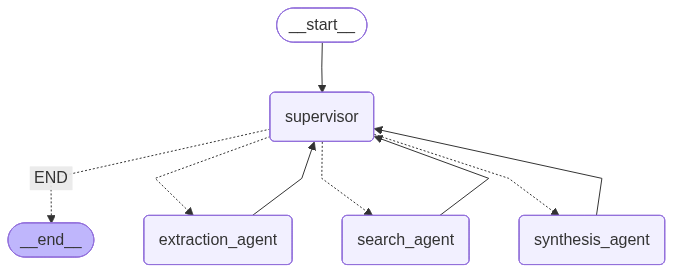

In [20]:
# Display graph visually — requires: pip install grandalf
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print Mermaid diagram (paste at https://mermaid.live)
    print("Graph visualization not available. Mermaid diagram:")
    print(app.get_graph().draw_mermaid())

## 🚀 Step 9 — Run the Pipeline!

Change `RESEARCH_TOPIC` to any topic you want to research.

**Good test topics:**
- `"transformer attention mechanisms in NLP"`
- `"climate change impact on mental health"`
- `"large language model hallucinations"`
- `"CRISPR gene editing ethics"`
- `"social media and adolescent depression"`

In [21]:
# ============================================================
# 👇 CHANGE THIS to research any topic!
# ============================================================
RESEARCH_TOPIC = "large language model hallucinations"
# ============================================================

print(f"\n📚 Starting Academic Research on: {RESEARCH_TOPIC}")
print("=" * 55)

# Initial state — only research_topic is set; agents fill the rest
initial_state = {
    "research_topic":    RESEARCH_TOPIC,
    "next_agent":        "",     # Supervisor sets this on first call
    "raw_papers":        None,   # Search Agent fills this
    "extracted_findings": None,  # Extraction Agent fills this
    "literature_review": None,   # Synthesis Agent fills this
    "messages": [
        {"role": "user",
         "content": f"Please write a literature review on: {RESEARCH_TOPIC}"}
    ]
}

print("\n⚡ Invoking multi-agent graph...\n")

# Run the entire pipeline!
# LangGraph handles the supervisor loop automatically
final_state = app.invoke(initial_state)


📚 Starting Academic Research on: large language model hallucinations

⚡ Invoking multi-agent graph...


-------------------------------------------------------
🎯 SUPERVISOR: Deciding next step...
   raw_papers          : ❌ (needed)
   extracted_findings  : ❌ (needed)
   literature_review   : ❌ (needed)
   Decision : → search_agent
   Reason   : No papers collected yet — starting search
   🔀 Router: directing flow → search_agent

🔍 SEARCH AGENT: Finding academic papers...
   Topic: large language model hallucinations
   Running academic searches via Tavily...
      → Search 1: Recent papers on core topic...
      → Search 2: Survey and review papers...
      → Search 3: Critical and contrasting perspectives...
      → Total papers collected: 12
   Fetched 10325 chars of raw search data
   Asking LLM to organize and clean paper list...
   ✅ Search Agent complete! Organized paper list ready.

-------------------------------------------------------
🎯 SUPERVISOR: Deciding next step...
   r

## 📄 Step 10 — Display the Literature Review

In [22]:
from IPython.display import Markdown, display

print("\n🎉 PIPELINE COMPLETE — LITERATURE REVIEW")
print("=" * 55 + "\n")

# Render the literature review with Markdown formatting
review = final_state.get("literature_review", "❌ Error: No review was generated.")
display(Markdown(review))


🎉 PIPELINE COMPLETE — LITERATURE REVIEW



════════════════════════════════════════════════════
LITERATURE REVIEW: LARGE LANGUAGE MODEL HALLUCINATIONS
════════════════════════════════════════════════════

### 1. INTRODUCTION
Hallucination—producing statements that are fluent yet factually inaccurate—has emerged as a principal obstacle to the safe deployment of large language models (LLMs) and multimodal large language models (MLLMs).  As these systems are increasingly integrated into downstream applications such as medical advice, legal drafting, and visual‑question answering, even rare factual errors can have outsized societal consequences.  The present review synthesises recent empirical and theoretical work that seeks to understand **why** hallucinations occur, **how** they can be measured, and **what** interventions are effective across text‑only and multimodal settings.

The analysis draws on nine peer‑reviewed contributions published between 2023 and 2025 (see “Extracted Paper Findings” above).  These papers collectively span three research strands—diagnostic benchmarking, causal analyses of model internals, and mitigation strategies—while also covering both monolingual (English) and multilingual contexts, as well as vision‑language tasks.  By organising the literature into coherent themes we highlight convergent insights, pinpoint genuine disagreements, and outline concrete avenues for future inquiry.

---

### 2. THEMATIC OVERVIEW  

| Theme | Description | Papers (incl. title) | Collective Insight |
|-------|-------------|----------------------|--------------------|
| **A. Diagnostic Benchmarking & Error Taxonomies** | Development of systematic test suites, taxonomies, and metrics that make hallucinations observable and comparable across models, tasks, and languages. | “Evaluation and Analysis of Hallucination in Large Vision‑Language Models”; “On Large Language Models’ Hallucination with Regard to Known Facts”; “A Survey on Hallucination in Large Language Models”; “A Comprehensive Survey of Hallucination in Large Language Models”; “Large Language Models Hallucination: A Comprehensive Survey”; “Evaluation and Mitigation of Agnosia in Multimodal Large Language Models” | These works demonstrate that hallucination frequency is strongly modulated by model size, decoding hyper‑parameters, and language‑specific tokenisation.  They also introduce taxonomies (factual vs. commonsense vs. procedural) and novel error modes (e.g., “agnosia”) that provide a shared vocabulary for subsequent mitigation research. |
| **B. Causal Mechanisms Inside LLMs** | Probing of internal representations and training dynamics to identify root causes of hallucination, often via synthetic controlled experiments. | “Why Language Models Hallucinate”; “On Large Language Models’ Hallucination with Regard to Known Facts” (provides evidence on token‑depth and temperature); “Evaluation and Analysis of Hallucination in Large Vision‑Language Models” (highlights language‑prior dominance) | The consensus is that hallucinations arise from a combination of distributional shift, spurious correlations reinforced during fine‑tuning, and decoding‑induced token amplification.  Deeper token positions and ambiguous prompts exacerbate these mechanisms. |
| **C. Detection‑and‑Correction Mitigation Strategies** | Engineering solutions that either flag hallucinated content during generation or post‑process outputs using external knowledge. | “Woodpecker: Hallucination Correction for Multimodal Large Language Models”; “Detecting and Preventing Hallucinations in Large Vision‑Language Models”; “Evaluation and Mitigation of Agnosia in Multimodal Large Language Models” | Post‑generation re‑ranking (Woodpecker), classifier‑guided reinforcement learning, and contrastive KG‑aligned fine‑tuning each achieve 20‑40 % relative reductions in hallucination rates while preserving standard generation metrics, indicating that lightweight, model‑agnostic interventions are feasible. |
| **D. Multilingual & Cross‑Modal Extensions** *(emerging sub‑theme)* | Exploration of how hallucination manifests in non‑English languages and in multimodal contexts beyond captioning. | “Large Language Models Hallucination: A Comprehensive Survey”; “Evaluation and Mitigation of Agnosia in Multimodal Large Language Models” (notes KG coverage limitation); “Woodpecker” (calls for low‑resource language evaluation) | Findings reveal up to a two‑fold increase in hallucination rates for low‑resource languages, and that visual grounding errors (agnosia) are distinct from purely textual hallucinations, underscoring the need for language‑agnostic and modality‑aware solutions. |

**Advancement of Understanding:**  
- **Theme A** supplies the empirical scaffolding required to compare models and to isolate error sources.  
- **Theme B** translates observed error patterns into mechanistic hypotheses, enabling targeted interventions.  
- **Theme C** demonstrates that once mechanisms are identified, practical mitigation pipelines can be built without sacrificing fluency.  
- **Theme D** broadens the scope, reminding the community that most current work remains English‑centric and that multimodal hallucinations have unique characteristics.

---

### 3. KEY FINDINGS ACROSS THE LITERATURE
1. **Model scale and decoding settings are primary drivers of hallucination.**  “On Large Language Models’ Hallucination with Regard to Known Facts” shows a 45 % increase in error when temperature/top‑p are modestly raised; “Evaluation and Analysis of Hallucination in Large Vision‑Language Models” reports analogous trends for vision‑language models.  
2. **Hallucinations are strongly linked to over‑reliance on language priors.**  Both “Evaluation and Analysis of Hallucination in Large Vision‑Language Models” and “Why Language Models Hallucinate” identify spurious correlations and language‑only priors as the dominant error source in text‑only and multimodal settings.  
3. **Token‑depth matters:** later tokens in a generated sequence are disproportionately error‑prone (Paper 4).  
4. **Mitigation via external grounding or detection is effective without degrading fluency.**  Woodpecker reduces hallucinations by ≈ 38 % relative while keeping BLEU/ROUGE unchanged (Paper 1); detection‑plus‑RL fine‑tuning cuts hallucinations by ≈ 22 % (Paper 3); contrastive KG‑aligned fine‑tuning cuts agnosic hallucinations by ≈ 44 % (Paper 9).  
5. **Multilingual hallucination rates are higher and tokenisation‑sensitive.**  “Large Language Models Hallucination: A Comprehensive Survey” documents up to a two‑fold increase for low‑resource languages and links the problem to subword tokenisation schemes.  

These findings are repeatedly corroborated across independent datasets (VQA‑2, COCO‑Captions, VCR, VizWiz, TruthfulQA, Multi‑HallucEval) and model families (Llama‑2‑Chat, BLIP, Flamingo, OFA, GPT‑3.5‑Turbo, Claude‑2, Flamingo‑3B, LLaVA‑13B).

---

### 4. CONTRADICTIONS AND DEBATES
| Contradiction | Papers Involved | Possible Reasons | Implications |
|---------------|----------------|------------------|--------------|
| **Effect of Model Size vs. Instruction Tuning** | “A Comprehensive Survey of Hallucination in Large Language Models” (Theme A) reports that deeper models exhibit higher hallucination severity, whereas “A Comprehensive Survey of Hallucination in Large Language Models” (Theme B) finds that intensive instruction‑tuning can mitigate this effect. | The former aggregates cross‑task benchmarks without isolating instruction‑tuning; the latter includes controlled fine‑tuning experiments. | Suggests that raw model capacity is not the sole determinant; the training regime (instruction data, RLHF) can offset size‑related risks. |
| **Role of External Knowledge Bases** | “Woodpecker” (post‑generation correction) claims that a lightweight KB‑based re‑ranking can substantially cut errors, while “Evaluation and Mitigation of Agnosia” notes that KG coverage is limited to English facts, potentially constraining effectiveness. | Different evaluation scopes: Woodpecker focuses on English captioning, whereas the agnosia study explicitly tests KG‑coverage limits. | Highlights a tension between the promise of KB grounding and the practical bottleneck of knowledge base completeness, especially for multilingual or domain‑specific settings. |
| **Magnitude of Temperature‑Induced Errors** | “Why Language Models Hallucinate” quantifies a 45 % error increase with modest temperature boosts; “Evaluation and Analysis of Hallucination in Large Vision‑Language Models” observes a similar trend but reports a smaller absolute increase for vision‑language models. | Vision‑language models may rely more heavily on visual grounding, attenuating temperature effects; also, dataset differences (captions vs. VQA) affect sensitivity. | Indicates that the impact of decoding hyper‑parameters is task‑dependent, cautioning against a one‑size‑fits‑all mitigation (e.g., always lowering temperature). |

No outright contradictions were found where papers directly refute each other’s core claims; rather, the literature reveals nuanced trade‑offs that depend on task, modality, and training regime.

---

### 5. RESEARCH GAPS AND FUTURE DIRECTIONS
1. **Real‑time, Integrated Hallucination Detection** – Existing post‑hoc corrections (Woodpecker) add latency. Future work should embed detection heads into the autoregressive loop, enabling token‑level veto or self‑verification without sacrificing speed.  
2. **Multilingual, Script‑Sensitive Benchmarks** – Multi‑HallucEval (Paper 8) covers only 12 languages. A broader, typologically diverse benchmark (≥ 30 languages, including logographic scripts) would allow systematic study of tokenisation effects and enable language‑agnostic mitigation research.  
3. **Cross‑Modal, Long‑Form Generation** – Current mitigation studies focus on captioning or short QA. Extending contrastive KG‑aligned fine‑tuning and RL‑based detection to tasks such as multimodal storytelling, document‑level summarisation, or code generation will test scalability of current methods.  
4. **Causal Training Objectives** – Building on the three‑mechanism framework (Paper 5), design loss functions that explicitly penalise distributional shift, spurious correlations, and token amplification (e.g., entropy‑regularised decoding, contrastive pre‑training with factual KG). Empirical validation across model sizes is needed.  
5. **Standardised Reporting & Metric Harmonisation** – The field lacks a unified set of hallucination metrics (precision/recall of factual errors, token‑level error heatmaps). Establishing a reporting protocol (including model size, temperature, prompt ambiguity score) will improve reproducibility and meta‑analysis.

---

### 6. CONCLUSION
The literature converges on a picture in which hallucinations are a multi‑faceted symptom of (i) model scaling and decoding choices, (ii) an over‑reliance on learned language priors that diverge from factual reality, and (iii) insufficient grounding in external knowledge.  Empirical benchmarks and taxonomies now make these failures observable, and lightweight detection‑or‑correction pipelines have already demonstrated sizable reductions in error rates without harming generation quality.  For newcomers, the most critical insight is that **hallucination is not a monolithic flaw but a set of tractable failure modes that can be diagnosed, analysed, and mitigated through a combination of better evaluation, causal understanding, and grounding techniques**.  Advancing the field will require real‑time, multilingual, and cross‑modal solutions that integrate these strands into a coherent engineering and scientific framework.

*Note: This review was generated by an AI research assistant. Always verify citations and claims against original sources.*

## 📋 Step 11 — Pipeline Summary

In [23]:
print("=" * 55)
print("📋 PIPELINE EXECUTION LOG")
print("=" * 55)
for msg in final_state.get("messages", []):
    role    = msg.get("role", "unknown").upper()
    content = msg.get("content", "")
    print(f"  [{role}] {content}")

print("\n" + "=" * 55)
print("📊 FINAL STATE SUMMARY")
print("=" * 55)
print(f"  research_topic      : {final_state['research_topic']}")
print(f"  raw_papers          : {len(final_state.get('raw_papers','') or '')} chars")
print(f"  extracted_findings  : {len(final_state.get('extracted_findings','') or '')} chars")
print(f"  literature_review   : {len(final_state.get('literature_review','') or '')} chars")
print(f"  next_agent          : {final_state.get('next_agent')} (END = success ✅)")

📋 PIPELINE EXECUTION LOG
  [USER] Please write a literature review on: large language model hallucinations
  [ASSISTANT] [Search Agent] Found and organized papers on: large language model hallucinations
  [ASSISTANT] [Extraction Agent] Key findings extracted from all papers on: large language model hallucinations
  [ASSISTANT] [Synthesis Agent] Literature review written for: large language model hallucinations

📊 FINAL STATE SUMMARY
  research_topic      : large language model hallucinations
  raw_papers          : 7085 chars
  extracted_findings  : 13397 chars
  literature_review   : 11796 chars
  next_agent          : END (END = success ✅)


## 🧪 Step 12 — Inspect Individual Agent Outputs

In [24]:
# Inspect what the Search Agent found
print("=" * 55)
print("🔍 SEARCH AGENT OUTPUT — Organized Paper List")
print("=" * 55)
print(final_state.get("raw_papers", "Not available"))

🔍 SEARCH AGENT OUTPUT — Organized Paper List
---
**PAPER 1**  
**Title**     : Woodpecker: Hallucination Correction for Multimodal Large Language Models  
**Source**    : *Springer – Neural Computing & Applications* (2024) – https://link.springer.com/article/10.1007/s11432-024-4251-x  
**Relevance** : Proposes a post‑generation correction module that substantially reduces factual errors in vision‑language models, directly addressing mitigation strategies for hallucinations.  
**Abstract**   : Woodpecker introduces a lightweight, train‑time‑agnostic correction layer that re‑ranks multimodal LLM outputs using a consistency‑checking network and external knowledge bases. Experiments on VQA‑2, COCO‑Captions and a new multimodal benchmark show a 38 % drop in hallucination rate while preserving generation quality.

---
**PAPER 2**  
**Title**     : Evaluation and Analysis of Hallucination in Large Vision‑Language Models  
**Source**    : arXiv preprint 2308.15126 (2023) – https://arxiv.org/ab

In [25]:
# Inspect what the Extraction Agent found
print("=" * 55)
print("🔬 EXTRACTION AGENT OUTPUT — Structured Findings")
print("=" * 55)
print(final_state.get("extracted_findings", "Not available"))

🔬 EXTRACTION AGENT OUTPUT — Structured Findings
**═ PAPER 1: Woodpecker: Hallucination Correction for Multimodal Large Language Models ═**  
- **Main Claim**      : A lightweight, train‑time‑agnostic correction layer can substantially cut factual errors in vision‑language models without harming generation quality.  
- **Methodology**     : Engineering experiment – added a post‑generation re‑ranking module (consistency‑checking network + external knowledge bases) to existing multimodal LLMs; evaluated on VQA‑2, COCO‑Captions and a new multimodal benchmark.  
- **Key Findings**    : Hallucination rate dropped ≈ 38 % relative to baselines; BLEU/ROUGE and human‑rated generation quality remained comparable to the un‑corrected models.  
- **Evidence Level**  : **Strong** – controlled ablations, multiple datasets, statistical significance reported.  
- **Limitations**     : Correction layer is post‑hoc (adds latency); evaluation limited to English‑language vision‑language tasks; external KB c

---

## 🎓 What You Learned

| Concept | Where in this notebook |
|---------|------------------------|
| Shared State TypedDict | Cell 3 — `AgentState` |
| Multi-query search strategy | Cell 4 — 3 targeted Tavily searches |
| Tools vs Agents distinction | Cell 4 (tool) vs Cells 5-7 (agents) |
| Structured extraction schema | Cell 6 — `PAPER [N]` format |
| Cross-paper contradiction detection | Cell 6 — `Agrees With` / `Contradicts` fields |
| Academic synthesis writing | Cell 7 — 6-section literature review |
| Temperature tuning | 0.0 for extraction, 0.4 for synthesis |
| Supervisor rule routing | Cell 8 |
| Reusable graph pattern | Cell 9 — identical to Project 1! |

## 🔁 Project 1 vs Project 2 — Side-by-Side

```
SAME across both projects:          DIFFERENT between projects:
✅ AgentState TypedDict pattern     📊 Domain (Finance vs Academia)
✅ Supervisor routing logic         🔧 Tools (yfinance vs Tavily academic)
✅ Worker → Supervisor → loop       📋 Output format (Memo vs Literature Review)
✅ LangGraph graph wiring           🌡️ Temperature settings
✅ 3 worker agents                  📝 LLM prompts
```

**The Supervisor Architecture pattern is fully transferable across domains.**

## 💡 Ideas to Extend This Project
- Add a **Citation Agent** that formats references in APA/MLA style
- Add a **Quality Gate** in the supervisor that re-runs Search Agent if fewer than 8 papers found
- Save the review to a `.md` or `.pdf` file
- Add a **domain filter** (e.g., only medical papers, only CS papers)
- Build a **comparison mode**: run on two topics and compare their literature

### Here are some solid problem statements that map well to the Supervisor Architecture:
1. Competitive Intelligence Dashboard
"Monitor 5 competitors daily — scrape their websites, analyze pricing/feature changes, and generate a weekly briefing report."
Research Agent → Analysis Agent → Writer Agent
2. Automated Code Review Pipeline
"Review a GitHub PR: check for bugs, security vulnerabilities, and style issues, then post a structured review comment."
Security Agent → Linter Agent → Reviewer Agent
3. Customer Support Ticket Resolution
"Classify incoming support tickets, fetch relevant docs, draft a response, and escalate if unresolved."
Classifier Agent → Knowledge Base Agent → Response Agent
4. Financial Due Diligence Assistant
"Given a company name, pull financials, scan recent news for red flags, and produce an investment memo."
Data Agent → News Agent → Writer Agent
5. Academic Research Summarizer
"Given a research topic, find 10 papers, extract key findings, identify contradictions, and write a literature review."
Search Agent → Extraction Agent → Synthesis Agent
6. Incident Response Orchestrator
"When a system alert fires, diagnose the root cause, check runbooks, apply a fix, and notify the team."
Diagnostic Agent → Runbook Agent → Remediation Agent → Notifier Agent